# Vend + Consumption Overlap EDA

This notebook focuses on the subset of consumers that have evidence of both Vend activity and Consumption activity.

Cohort definition used here:

- start from `Consumer Master` as the anchor table
- keep only consumers with matched vend records
- keep only consumers with matched consumption records
- use the dashboard's conservative resolved-master matching rather than forcing a direct vend-to-consumption merge

That gives us a safer overlap cohort for exploratory analysis and daily trend charts.

In [1]:
from __future__ import annotations

# Standard library imports for project-root discovery and local imports.
from pathlib import Path
import sys

# Core analysis libraries for wrangling and plotting.
import pandas as pd
import plotly.express as px
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    # Walk upward until we find the repo structure expected by this notebook.
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and config/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: F:\Secure\CashFlowMgmt


In [2]:
from src.analytics import build_dashboard_analytics
from src.path_utils import load_app_config


APP_CONFIG = load_app_config(PROJECT_ROOT / "config" / "app_config.yaml")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

consumer_master_df = pd.read_parquet(PROCESSED_DIR / "consumer_master.parquet")
vend_df = pd.read_parquet(PROCESSED_DIR / "vend.parquet")
consumption_df = pd.read_parquet(PROCESSED_DIR / "consumption.parquet")

# Reuse the dashboard analytics layer so this notebook follows the same join logic and field preparation.
analytics = build_dashboard_analytics(
    master_df=consumer_master_df,
    vend_df=vend_df,
    consumption_df=consumption_df,
    app_config=APP_CONFIG,
)

consumer_summary = analytics["datasets"]["consumer_summary"]
vend_enriched = analytics["datasets"]["vend_enriched"]
consumption_enriched = analytics["datasets"]["consumption_enriched"]
vend_timestamp_quality = analytics["vend_timestamp_quality"]

display(pd.DataFrame([vend_timestamp_quality]))

,total_rows,full_datetime_rows,date_only_rows,time_only_rows,missing_rows,failed_rows,calendar_coverage_pct,quality_label,supports_daily_analysis,supports_intraday_analysis,note
0,1503445,1503445,0,0,0,0,100.0,full_datetime,True,True,Issuedate quality supports daily and intraday ...


## Build the overlap cohort

The cohort is defined at the master-consumer level. We then pull through the vend and consumption rows that resolve back to those same consumers.

In [3]:
# Keep only master consumers that have both activity types after conservative matching.
cohort_consumers = consumer_summary[
    consumer_summary.get("has_vend_records", pd.Series(dtype="bool")).fillna(False)
    & consumer_summary.get("has_consumption_records", pd.Series(dtype="bool")).fillna(False)
].copy()

cohort_master_ids = set(cohort_consumers["consumer_master_id"].dropna().astype("Int64").tolist())

cohort_vend = vend_enriched[vend_enriched.get("resolved_master_id").isin(cohort_master_ids)].copy()
cohort_consumption = consumption_enriched[consumption_enriched.get("resolved_master_id").isin(cohort_master_ids)].copy()

# Prepare numeric and daily fields for aggregation.
cohort_vend["transactionamount_numeric"] = pd.to_numeric(cohort_vend.get("transactionamount"), errors="coerce")
cohort_vend["vend_date"] = pd.to_datetime(cohort_vend.get("vend_date"), errors="coerce")

cohort_consumption["kwh_consumption_numeric"] = pd.to_numeric(cohort_consumption.get("kwh_consumption"), errors="coerce")
cohort_consumption["kvah_consumption_numeric"] = pd.to_numeric(cohort_consumption.get("kvah_consumption"), errors="coerce")
cohort_consumption["date"] = pd.to_datetime(cohort_consumption.get("date"), errors="coerce")

cohort_summary = pd.DataFrame([
    {
        "matched_consumers": int(len(cohort_consumers)),
        "vend_rows_for_cohort": int(len(cohort_vend)),
        "consumption_rows_for_cohort": int(len(cohort_consumption)),
        "vend_date_min": cohort_vend["vend_date"].min(),
        "vend_date_max": cohort_vend["vend_date"].max(),
        "consumption_date_min": cohort_consumption["date"].min(),
        "consumption_date_max": cohort_consumption["date"].max(),
    }
])

display(cohort_summary)

if cohort_consumers.empty:
    print("No overlap cohort was found. If that is unexpected, inspect key coverage and match quality before trusting daily comparisons.")

,matched_consumers,vend_rows_for_cohort,consumption_rows_for_cohort,vend_date_min,vend_date_max,consumption_date_min,consumption_date_max
0,0,0,0,NaT,NaT,NaT,NaT


No overlap cohort was found. If that is unexpected, inspect key coverage and match quality before trusting daily comparisons.


## Basic EDA

These summaries help us understand the size, intensity, and distribution of activity for the overlap cohort before plotting daily totals.

In [4]:
eda_metrics = pd.DataFrame([
    {
        "matched_consumers": int(len(cohort_consumers)),
        "avg_vend_amount_per_txn": cohort_vend["transactionamount_numeric"].mean(),
        "median_vend_amount_per_txn": cohort_vend["transactionamount_numeric"].median(),
        "avg_daily_kwh_row": cohort_consumption["kwh_consumption_numeric"].mean(),
        "median_daily_kwh_row": cohort_consumption["kwh_consumption_numeric"].median(),
        "avg_daily_kvah_row": cohort_consumption["kvah_consumption_numeric"].mean(),
        "median_daily_kvah_row": cohort_consumption["kvah_consumption_numeric"].median(),
        "total_vend_amount": cohort_vend["transactionamount_numeric"].sum(),
        "total_kwh_consumption": cohort_consumption["kwh_consumption_numeric"].sum(),
    }
])

consumer_level_eda = (
    cohort_consumers[[
        "consumer_master_id",
        "consumername",
        "consumernumber",
        "meterno",
        "tariffcode",
        "area_type",
        "vend_transaction_count",
        "vend_total_amount",
        "average_daily_kwh",
        "average_daily_kvah",
        "meterbalance",
    ]]
    .sort_values(["vend_total_amount", "average_daily_kwh"], ascending=False)
)

display(eda_metrics)
display(cohort_vend[["transactionamount_numeric"]].describe().T)
display(cohort_consumption[["kwh_consumption_numeric", "kvah_consumption_numeric"]].describe().T)
display(consumer_level_eda.head(20))

,matched_consumers,avg_vend_amount_per_txn,median_vend_amount_per_txn,avg_daily_kwh_row,median_daily_kwh_row,avg_daily_kvah_row,median_daily_kvah_row,total_vend_amount,total_kwh_consumption
0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
transactionamount_numeric,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


,count,mean,std,min,25%,50%,75%,max
kwh_consumption_numeric,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
kvah_consumption_numeric,0.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


,consumer_master_id,consumername,consumernumber,meterno,tariffcode,area_type,vend_transaction_count,vend_total_amount,average_daily_kwh,average_daily_kvah,meterbalance


In [5]:
# Build consumer-level activity depth summaries to show how concentrated the cohort is.
vend_by_consumer = (
    cohort_vend.dropna(subset=["resolved_master_id"])
    .groupby("resolved_master_id", dropna=True)
    .agg(
        vend_txn_count=("transactionamount_numeric", "size"),
        vend_total_amount=("transactionamount_numeric", "sum"),
        vend_avg_amount=("transactionamount_numeric", "mean"),
    )
    .reset_index()
)

consumption_by_consumer = (
    cohort_consumption.dropna(subset=["resolved_master_id"])
    .groupby("resolved_master_id", dropna=True)
    .agg(
        consumption_day_count=("kwh_consumption_numeric", "size"),
        total_kwh=("kwh_consumption_numeric", "sum"),
        avg_daily_kwh=("kwh_consumption_numeric", "mean"),
    )
    .reset_index()
)

cohort_depth = (
    cohort_consumers[["consumer_master_id", "consumername", "consumernumber", "tariffcode", "area_type"]]
    .merge(vend_by_consumer, how="left", left_on="consumer_master_id", right_on="resolved_master_id")
    .drop(columns=["resolved_master_id"], errors="ignore")
    .merge(consumption_by_consumer, how="left", left_on="consumer_master_id", right_on="resolved_master_id")
    .drop(columns=["resolved_master_id"], errors="ignore")
)

display(cohort_depth.head(20))

,consumer_master_id,consumername,consumernumber,tariffcode,area_type,vend_txn_count,vend_total_amount,vend_avg_amount,consumption_day_count,total_kwh,avg_daily_kwh


## Daily series for the overlap cohort

The three charts below are built from the same overlap cohort:

1. total daily consumption
2. total daily vend amounts
3. average rupees per kWh received per day

The rupees-per-kWh series is calculated as `total daily vend amount / total daily kWh consumption` for the cohort on each date where daily kWh is positive.

In [6]:
daily_consumption = (
    cohort_consumption.dropna(subset=["date"])
    .groupby("date", dropna=True)["kwh_consumption_numeric"]
    .sum()
    .reset_index(name="total_daily_kwh")
    .sort_values("date")
)

if vend_timestamp_quality.get("supports_daily_analysis", False):
    daily_vend = (
        cohort_vend.dropna(subset=["vend_date"])
        .groupby("vend_date", dropna=True)["transactionamount_numeric"]
        .sum()
        .reset_index(name="total_daily_vend_amount")
        .sort_values("vend_date")
        .rename(columns={"vend_date": "date"})
    )
else:
    daily_vend = pd.DataFrame(columns=["date", "total_daily_vend_amount"])
    print("Vend issuedate quality does not safely support calendar-day analysis in this extract.")

daily_combined = (
    daily_consumption.merge(daily_vend, on="date", how="outer")
    .sort_values("date")
)
daily_combined["total_daily_kwh"] = daily_combined["total_daily_kwh"].fillna(0)
daily_combined["total_daily_vend_amount"] = daily_combined["total_daily_vend_amount"].fillna(0)
daily_combined["avg_rupees_per_kwh"] = (
    daily_combined["total_daily_vend_amount"] / daily_combined["total_daily_kwh"].where(daily_combined["total_daily_kwh"] > 0)
)

display(daily_combined.head(20))

,date,total_daily_kwh,total_daily_vend_amount,avg_rupees_per_kwh


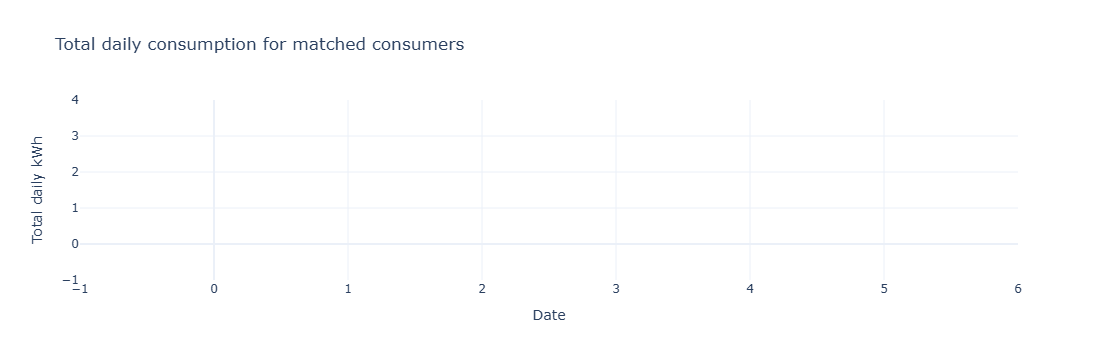

In [7]:
# Chart 1: total daily consumption for the overlap cohort.
fig_consumption = px.line(
    daily_consumption,
    x="date",
    y="total_daily_kwh",
    markers=True,
    title="Total daily consumption for matched consumers",
)
fig_consumption.update_layout(template="plotly_white", xaxis_title="Date", yaxis_title="Total daily kWh")
fig_consumption.show()

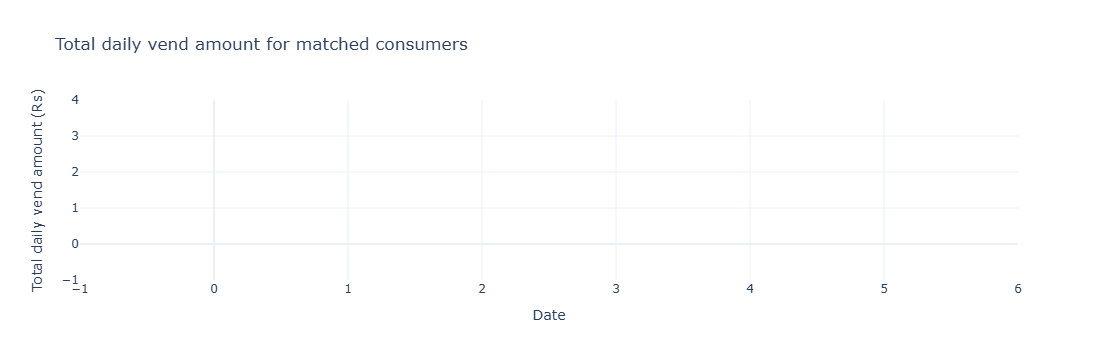

In [8]:
# Chart 2: total daily vend amount for the same matched cohort.
fig_vend = px.line(
    daily_vend,
    x="date",
    y="total_daily_vend_amount",
    markers=True,
    title="Total daily vend amount for matched consumers",
)
fig_vend.update_layout(template="plotly_white", xaxis_title="Date", yaxis_title="Total daily vend amount (Rs)")
fig_vend.show()

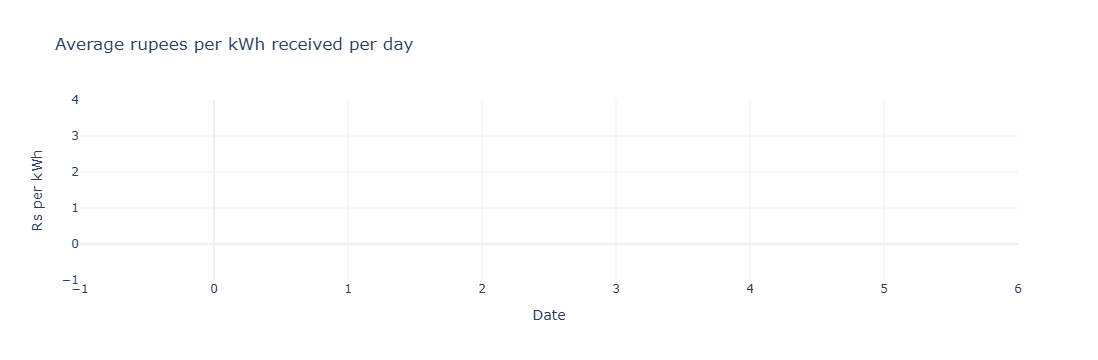

In [9]:
# Chart 3: daily rupees received per kWh consumed for the overlap cohort.
rupees_per_kwh_daily = daily_combined.dropna(subset=["avg_rupees_per_kwh"]).copy()

fig_ratio = px.line(
    rupees_per_kwh_daily,
    x="date",
    y="avg_rupees_per_kwh",
    markers=True,
    title="Average rupees per kWh received per day",
)
fig_ratio.update_layout(template="plotly_white", xaxis_title="Date", yaxis_title="Rs per kWh")
fig_ratio.show()

## Notes

If the overlap cohort is much smaller than expected, the next thing to inspect is join coverage quality, duplicate master keys, and whether vend and consumption are aligning through different identifiers.